# Kronos 金融K线预测
## NeoQuasar · 45+交易所 · Gradio WebUI

---


## 一、项目简介

### 1.1 官方模型

Kronos 由 NeoQuasar 团队发布，是全球首个专为金融K线图设计的基础模型。
它采用两阶段框架：专用分词器将 OHLCV 数据量化为分层离散令牌，然后用自回归 Transformer 进行预测。
训练数据来自全球 45+ 家交易所的现货、永续合约和期货历史数据，总时长超过 30 年。

### 1.2 本项目

- **实现类型**：推理 + WebUI（Gradio 时序预测界面）
- **模型**：Kronos-small（24.7M 参数，~94MB）/ Kronos-base（102.3M 参数，~390MB）
- **推理引擎**：PyTorch 2.1.1 + CUDA 12.1
- **许可证**：CC BY-NC-SA 4.0（非商业使用）

### 1.3 界面截图


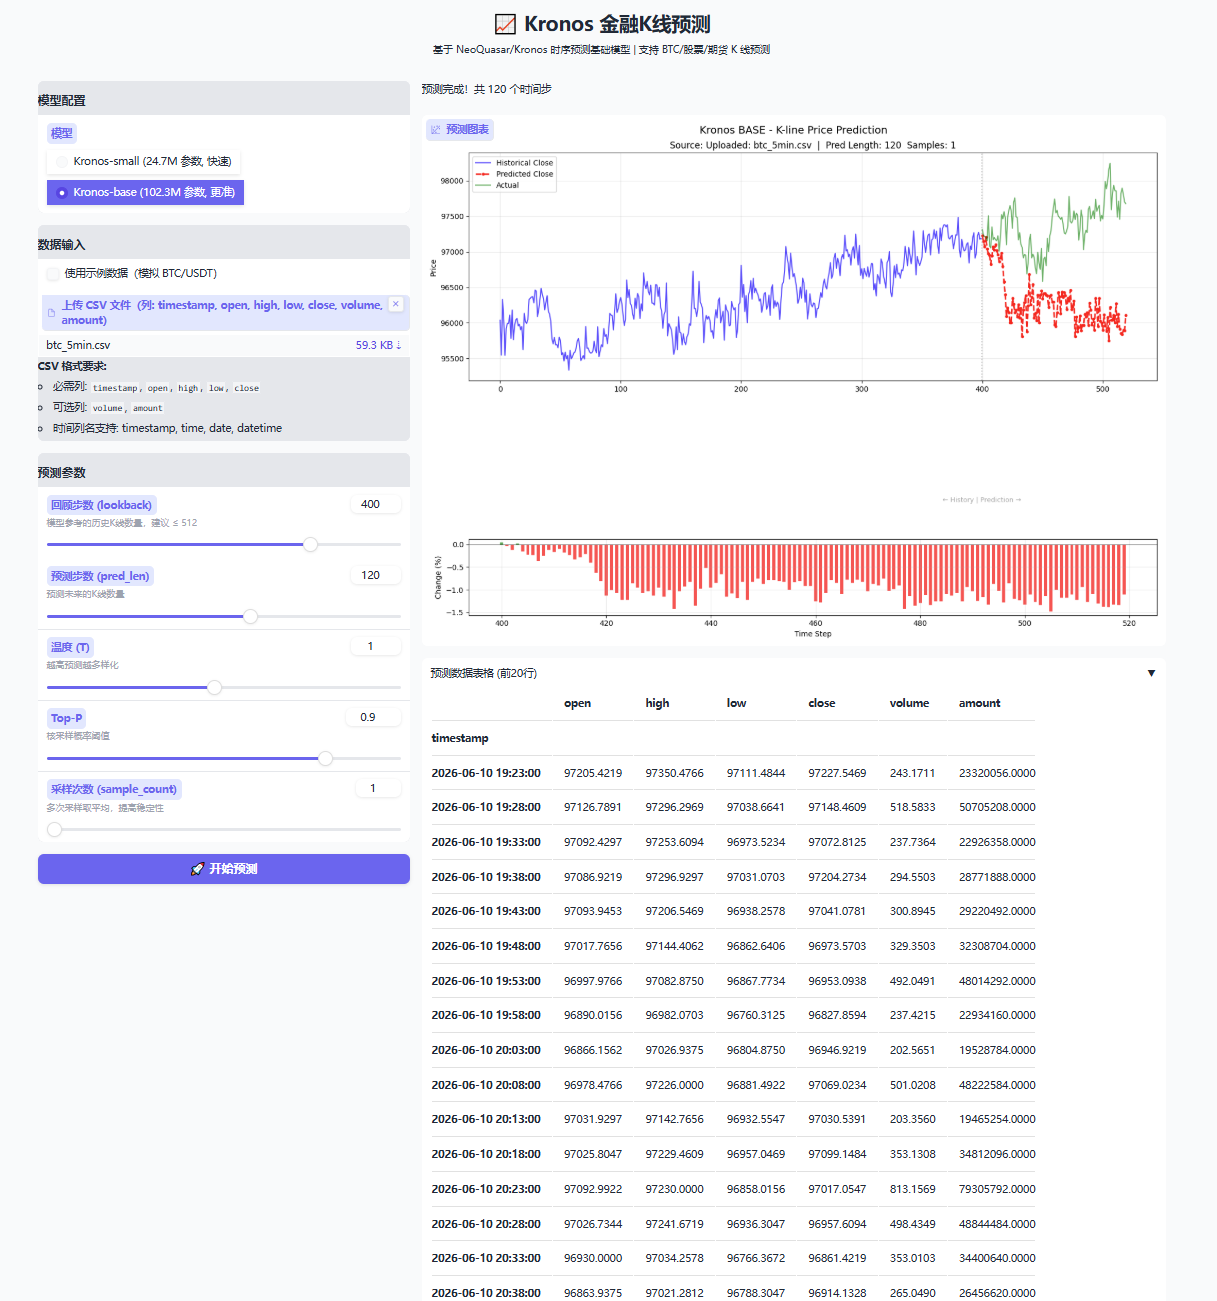

---

## 二、官方链接

| 资源 | 链接 |
|------|------|
| HuggingFace | https://huggingface.co/NeoQuasar |
| GitHub | https://github.com/shiyu-coder/Kronos |
| 论文 (arXiv) | https://arxiv.org/abs/2508.02739 |
| 官方集合 | https://huggingface.co/NeoQuasar |


---

## 三、算力推荐

| 用途 | GPU | 显存 |
|------|-----|:--:|
| 最低运行（Kronos-small） | B1.small / T4 | 6GB |
| 流畅运行（Kronos-base） | B1.large / A10 | 24GB |
| 高效采样（多次预测平均） | A100 | 40GB |

> 已验证 B1.small（6GB 显存）可流畅运行 small 和 base 两种模型，预测 120 步约 20-40 秒。

---

## 四、推理服务配置

| 参数 | 值 |
|------|-----|
| 镜像 | Kronos 自构建镜像 |
| 模型 | 已挂载 /gemini/pretrain/Kronos（含 Tokenizer-base / small / base） |
| 代码 | /gemini/code（只读挂载） |
| 启动命令 | `bash /gemini/code/start.sh` |
| 端口 | 7860 |
| 路由模式 | 按路径路由 |


---

## 五、使用说明

### 5.1 一键启动

```bash
cd /gemini/code
bash start.sh
```

### 5.2 访问地址

点击平台 Web 服务，开放端口 **7860** 后访问对应公网地址。

### 5.3 操作步骤

1. 选择模型（Kronos-small 快速 / Kronos-base 更准）
2. 选择数据来源：勾选「使用示例数据」= 模拟 BTC 5分钟K线；取消勾选可上传 CSV
3. 设置预测参数（回顾步数、预测步数、温度等）
4. 点击 **「Start Prediction」** 按钮
5. 等待 20-40 秒，查看预测价格曲线和涨跌幅图表


### 5.4 高级参数

| 参数 | 默认值 | 范围 | 说明 |
|------|:-----:|:----:|------|
| 回顾步数 (lookback) | 400 | 50~512 | 模型参考的历史K线数量 |
| 预测步数 (pred_len) | 120 | 10~200 | 预测未来的K线数量（5分K×120=10小时） |
| 温度 (T) | 1.0 | 0.1~2.0 | 越高预测越多样化 |
| Top-P | 0.9 | 0.5~1.0 | 核采样概率阈值 |
| 采样次数 | 1 | 1~10 | 多次采样取平均提高稳定性 |

### 5.5 CSV 格式

必需列：`timestamp`（时间戳）, `open`, `high`, `low`, `close`

可选列：`volume`, `amount`

时间列名支持：timestamp / time / date / datetime

```
timestamp,open,high,low,close,volume,amount
2026-06-10 00:00:00,97100.00,97250.00,97000.00,97150.00,526.31,51000000.00
2026-06-10 00:05:00,97150.00,97300.00,97080.00,97220.00,483.75,49200000.00
...
```
